The data collection phase was succesful.  Now it is time to clean the data, after looking at the CSV file,
there are some changes need on how the country was saved ES to Spain.  

In [140]:
import numpy as np
import pandas as pd

breakers_raw = pd.read_csv('C:\\ironhack\\labs\\breaker-detection-project\\data\\data\\breaker_dataset.csv')


In [141]:
breakers = breakers_raw.copy()


In [142]:
breakers.head()

,filename,timestamp,country,panel_age,phase_type,has_rcd,has_rcd_si,has_iga,iga_amp,has_ovp,mcb_values,num_mcbs,comments,number_rcd
0,08991740-04c2-4925-8fbf-27c878867339.jpg,2026-03-05T23:35:37,ES,15 años,1,1,1,0.0,0,0,"10,16,20,20",4,Hard to read mcb_value,1
1,08bf2ea5-6c4b-4fe4-8c6e-368e5bf3a025.jpg,2026-03-05T23:35:50,ES,5-10 años,1,1,0,1.0,25,0,"10,16,16",3,4,1
2,09f51da3-4395-46a1-858b-69fd2a973ed4.jpg,2026-03-05T23:36:12,ES,10-15 años,3,1,1,1.0,80,0,"6,6,10,10,10,10,16,16,20,20,20,25,25,25,32",15,13,5
3,132bb9c5-82d5-477d-9cf8-2901e936bd47.jpg,2026-03-05T23:36:26,ES,15 años,1,1,0,1.0,32,0,"10,16,20,25",4,4,1
4,163d9435-108a-48bb-a864-46e40d2aa6b6.jpg,2026-03-05T23:36:38,ES,> 20 years,1,1,0,1.0,32,0,"10,15,20,25",4,4,1


In [143]:
# Replace ES with SPAIN
breakers['country'] = breakers['country'].replace('ES','SPAIN')
breakers.head()

,filename,timestamp,country,panel_age,phase_type,has_rcd,has_rcd_si,has_iga,iga_amp,has_ovp,mcb_values,num_mcbs,comments,number_rcd
0,08991740-04c2-4925-8fbf-27c878867339.jpg,2026-03-05T23:35:37,SPAIN,15 años,1,1,1,0.0,0,0,"10,16,20,20",4,Hard to read mcb_value,1
1,08bf2ea5-6c4b-4fe4-8c6e-368e5bf3a025.jpg,2026-03-05T23:35:50,SPAIN,5-10 años,1,1,0,1.0,25,0,"10,16,16",3,4,1
2,09f51da3-4395-46a1-858b-69fd2a973ed4.jpg,2026-03-05T23:36:12,SPAIN,10-15 años,3,1,1,1.0,80,0,"6,6,10,10,10,10,16,16,20,20,20,25,25,25,32",15,13,5
3,132bb9c5-82d5-477d-9cf8-2901e936bd47.jpg,2026-03-05T23:36:26,SPAIN,15 años,1,1,0,1.0,32,0,"10,16,20,25",4,4,1
4,163d9435-108a-48bb-a864-46e40d2aa6b6.jpg,2026-03-05T23:36:38,SPAIN,> 20 years,1,1,0,1.0,32,0,"10,15,20,25",4,4,1


In [144]:
# Replace años with years
breakers['panel_age']= breakers['panel_age'].str.replace('años','years')

breakers.head()

,filename,timestamp,country,panel_age,phase_type,has_rcd,has_rcd_si,has_iga,iga_amp,has_ovp,mcb_values,num_mcbs,comments,number_rcd
0,08991740-04c2-4925-8fbf-27c878867339.jpg,2026-03-05T23:35:37,SPAIN,15 years,1,1,1,0.0,0,0,"10,16,20,20",4,Hard to read mcb_value,1
1,08bf2ea5-6c4b-4fe4-8c6e-368e5bf3a025.jpg,2026-03-05T23:35:50,SPAIN,5-10 years,1,1,0,1.0,25,0,"10,16,16",3,4,1
2,09f51da3-4395-46a1-858b-69fd2a973ed4.jpg,2026-03-05T23:36:12,SPAIN,10-15 years,3,1,1,1.0,80,0,"6,6,10,10,10,10,16,16,20,20,20,25,25,25,32",15,13,5
3,132bb9c5-82d5-477d-9cf8-2901e936bd47.jpg,2026-03-05T23:36:26,SPAIN,15 years,1,1,0,1.0,32,0,"10,16,20,25",4,4,1
4,163d9435-108a-48bb-a864-46e40d2aa6b6.jpg,2026-03-05T23:36:38,SPAIN,> 20 years,1,1,0,1.0,32,0,"10,15,20,25",4,4,1


In [145]:
# drop row where there are many NA due to a bad image that was unreadable by the labeler
breakers = breakers[breakers['filename'] != '08991740-04c2-4925-8fbf-27c878867339.jpg']


In [146]:
#change timestamps to datatime
breakers['timestamp'] = pd.to_datetime(breakers['timestamp'])

In [147]:
#convert all columns that start with has from floats to ints
has_cols = [c for c in breakers.columns if c.startswith('has_')]

breakers[has_cols] = breakers[has_cols].fillna(0).astype(int)

In [148]:
print(breakers.dtypes)



filename                 str
timestamp     datetime64[us]
country                  str
panel_age                str
phase_type             int64
has_rcd                int64
has_rcd_si             int64
has_iga                int64
iga_amp                int64
has_ovp                int64
mcb_values               str
num_mcbs               int64
comments                 str
number_rcd             int64
dtype: object


In [149]:
# convert strings from mcb_values so math can be performed on amparage values
breakers['mcb_values'] = breakers['mcb_values'].apply(lambda x: [int(v) for v in str(x).split(',') if v.strip().isdigit()])


In [150]:
# change iga_amp from float to int
breakers['iga_amp'] = breakers['iga_amp'].fillna(0).astype(int)


In [151]:
print(breakers.dtypes)



filename                 str
timestamp     datetime64[us]
country                  str
panel_age                str
phase_type             int64
has_rcd                int64
has_rcd_si             int64
has_iga                int64
iga_amp                int64
has_ovp                int64
mcb_values            object
num_mcbs               int64
comments                 str
number_rcd             int64
dtype: object


In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


In [153]:
ovp_counts = breakers['has_ovp'].value_counts()
ovp_percentages = breakers['has_ovp'].value_counts(normalize=True) * 100


ovp_summary = pd.DataFrame({
    'Count': ovp_counts,
    'Percentage': ovp_percentages
})

ovp_summary.index = ovp_summary.index.map({1: 'Has OVP (Protects equipment from surges)', 0: 'Lacks OVP (Does not offer protection)'})

print("Overall OVP Distribution:")
print(ovp_summary)
print("\nTotal panels analyzed:", len(breakers))
print('It is important to note that most of the Over Voltage Protection were installed by me and my team.\nSuggesting that the percentage of panels with OVP is likely much lower.')

Overall OVP Distribution:
                                          Count  Percentage
has_ovp                                                    
Lacks OVP (Does not offer protection)        46   90.196078
Has OVP (Protects equipment from surges)      5    9.803922

Total panels analyzed: 51
It is important to note that most of the Over Voltage Protection were installed by me and my team.
Suggesting that the percentage of panels with OVP is likely much lower.


In [154]:
# 1. Look at the distribution across ALL age groups
age_ovp_dist = pd.crosstab(breakers['panel_age'], breakers['has_ovp'], normalize='index') * 100
age_ovp_dist.columns = ['Lacks OVP (%)', 'Has OVP (%)']

print("OVP Adoption by Panel Age:")
print(age_ovp_dist.sort_index()) # Note: alphabetical sort might need manual reordering if preferred

# 2. Specifically isolate "Newer Panels" (< 5 years)
new_panels = breakers[breakers['panel_age'] == '< 5 years']
new_ovp_stats = new_panels['has_ovp'].value_counts(normalize=True) * 100

print("\n--- Deep Dive: Panels < 5 Years Old ---")
if not new_panels.empty:
    print(f"Total new panels: {len(new_panels)}")
    print(f"Percentage with OVP: {new_ovp_stats.get(1, 0):.1f}%")
    print(f"Percentage MISSING OVP: {new_ovp_stats.get(0, 0):.1f}%")
else:
    print("No panels found in the '< 5 years' category.")


OVP Adoption by Panel Age:
             Lacks OVP (%)  Has OVP (%)
panel_age                              
10-15 years          100.0          0.0
15 years             100.0          0.0
5-10 years           100.0          0.0
< 5 years              0.0        100.0
> 20 years           100.0          0.0

--- Deep Dive: Panels < 5 Years Old ---
Total new panels: 5
Percentage with OVP: 100.0%
Percentage MISSING OVP: 0.0%


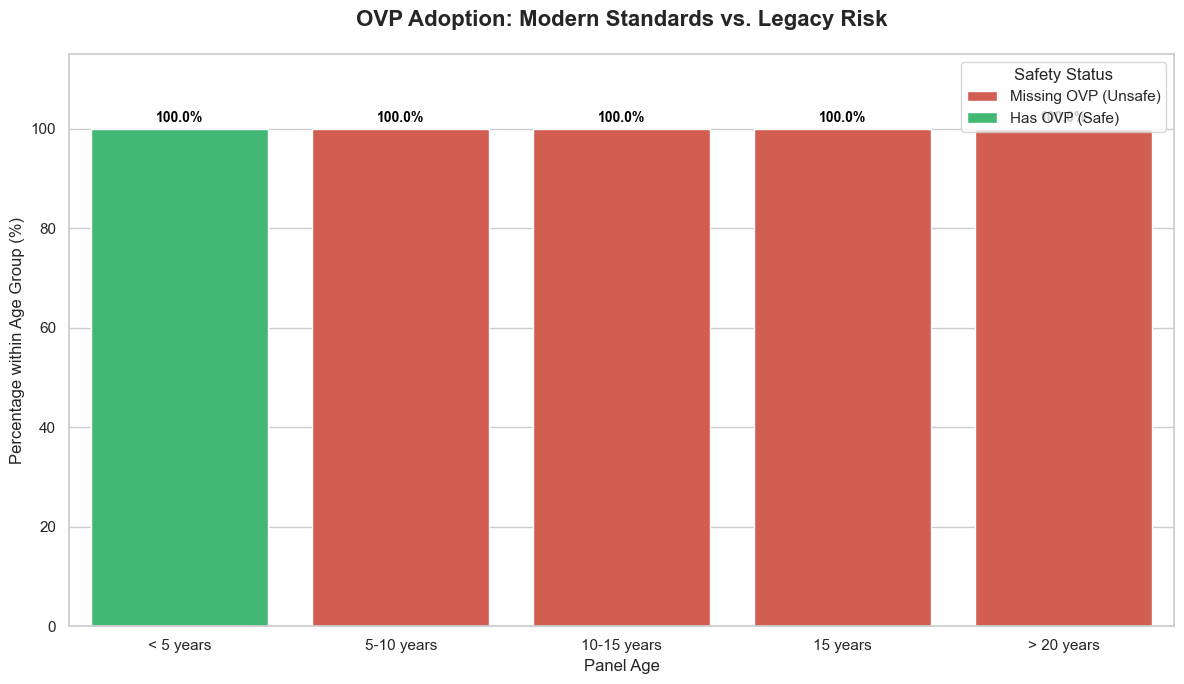

In [155]:
import seaborn as sns

# 1. Prepare the data for plotting
# Calculate percentages within each age group
plot_data = breakers.groupby('panel_age')['has_ovp'].value_counts(normalize=True).rename('percentage').reset_index()
plot_data['percentage'] *= 100
plot_data['Protection Status'] = plot_data['has_ovp'].map({0: 'Missing OVP (Unsafe)', 1: 'Has OVP (Safe)'})

# 2. Define the chronological order for the X-axis
age_order = ['< 5 years', '5-10 years', '10-15 years', '15 years', '> 20 years']

# 3. Create the plot
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_data, 
    x='panel_age', 
    y='percentage', 
    hue='Protection Status', 
    order=age_order,
    palette={'Missing OVP (Unsafe)': '#e74c3c', 'Has OVP (Safe)': '#2ecc71'}
)

# 4. Add titles and labels
plt.title('OVP Adoption: Modern Standards vs. Legacy Risk', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Percentage within Age Group (%)', fontsize=12)
plt.xlabel('Panel Age', fontsize=12)
plt.ylim(0, 115) # Extra space for labels

# 5. Add percentage labels on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', 
                    fontsize=10, color='black', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontweight='bold')

plt.legend(title='Safety Status', loc='upper right')
plt.tight_layout()
plt.show()


In [156]:
#make a list of all the mcbs in one column
all_mcbs = [amp for mcb in breakers['mcb_values'] for amp in mcb]


C:\Users\PC GAMING\AppData\Local\Temp\ipykernel_92460\2705055447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=all_mcbs_sorted, palette='viridis')


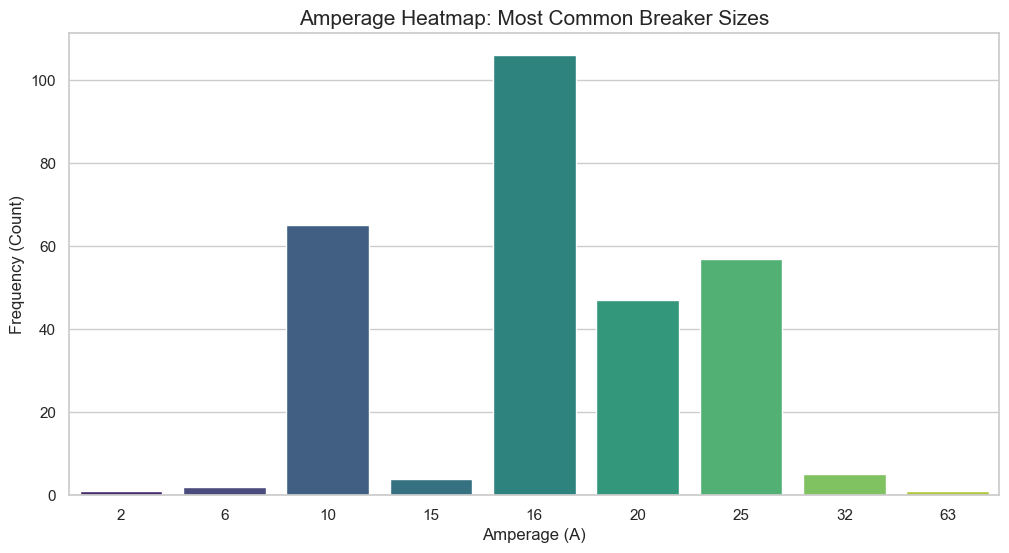

In [157]:

plt.figure(figsize=(12,6))

all_mcbs_sorted = sorted(all_mcbs)

sns.countplot(x=all_mcbs_sorted, palette='viridis')

#title the heatmap
plt.title('Amperage Heatmap: Most Common Breaker Sizes', fontsize=15)
plt.xlabel('Amperage (A)')
plt.ylabel('Frequency (Count)')
plt.show()

In [158]:
#Create a new feature, ratio of RCDs to MCBs
breakers['rcd_load_ratio']= breakers['num_mcbs']/breakers['number_rcd']

#Flag boards that have a high ratio of MCBs 'It is recomended to have at most 5'
breakers['is_overloaded'] = breakers['rcd_load_ratio'] > 5

#How many are currently violating the rule of 5?
breakers['is_overloaded'].value_counts()



is_overloaded
False    45
True      6
Name: count, dtype: int64

In [159]:
#Create a subset to avoid dividing by zero, as there are some panels that have no RCD
# Create a temporary subset 
panels_with_rcds = breakers[breakers['number_rcd'] > 0].copy()

# recalculate the ratio on the new subset
panels_with_rcds['rcd_load_ratio'] = panels_with_rcds['num_mcbs'] / panels_with_rcds['number_rcd']

#Calculate the average
print(f"Average MCBs per RCD: {panels_with_rcds['rcd_load_ratio'].mean():.2f}")


Average MCBs per RCD: 3.82


In [160]:
#On average there are enough RCDs

In [161]:
breakers['total_mcb_amp'] = breakers['mcb_values'].apply(sum)

In [162]:
breakers[['mcb_values', 'total_mcb_amp']].head()

,mcb_values,total_mcb_amp
1,"[10, 16, 16]",42
2,"[6, 6, 10, 10, 10, 10, 16, 16, 20, 20, 20, 25,...",251
3,"[10, 16, 20, 25]",71
4,"[10, 15, 20, 25]",70
5,"[16, 25, 32]",73


In [163]:
#Avoid divide by zero error by creating a mask. 
has_iga_mask= breakers['iga_amp'] > 0

#Simultaneity is the amount of theoretical your circuits could use if they were all at their maximum. In practice this is almost never the case.
breakers['simultaneity_ratio'] = np.nan

breakers.loc[has_iga_mask, 'simultaneity_ratio'] = breakers['total_mcb_amp']/ breakers['iga_amp']

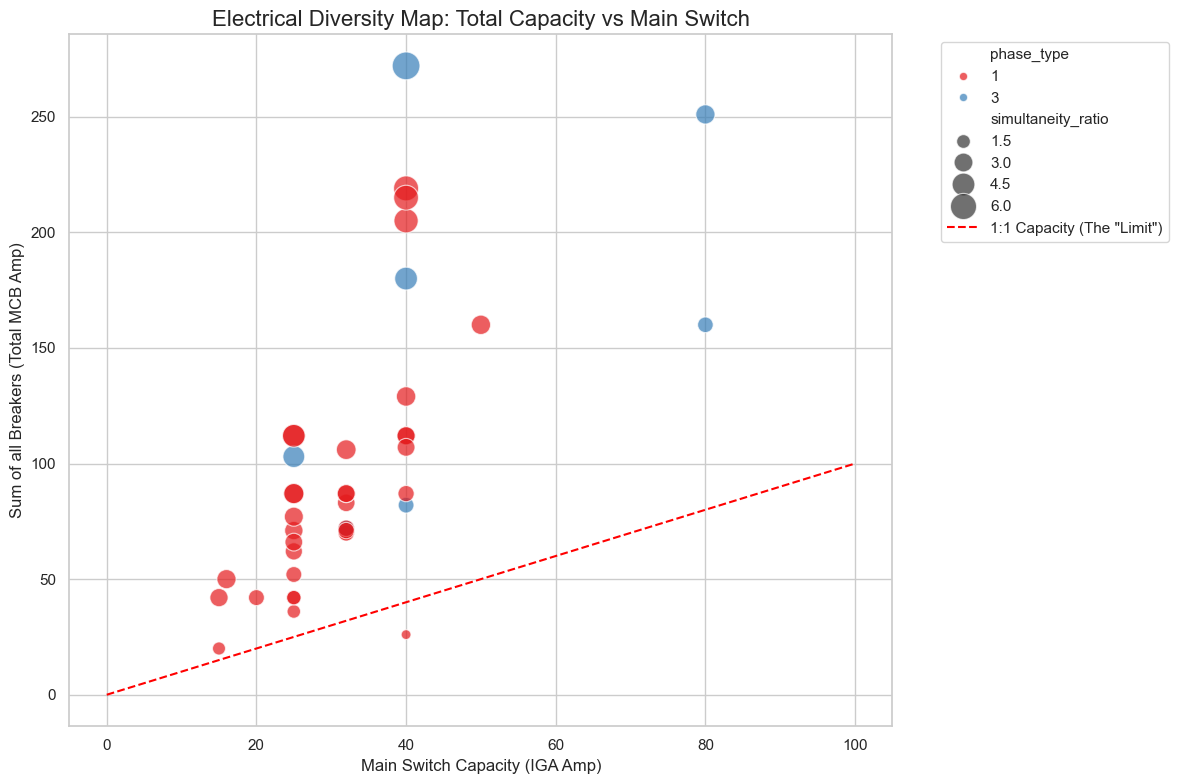

In [164]:
plt.figure(figsize=(12, 8))

# 1. Plot the Scatter/Bubble Chart
ax = sns.scatterplot(
    data=breakers[has_iga_mask], 
    x='iga_amp', 
    y='total_mcb_amp', 
    hue='phase_type',        # Color by phase
    size='simultaneity_ratio', # Size by risk ratio
    sizes=(50, 400),        # Scale the bubbles for visibility
    palette='Set1',         
    alpha=0.7               
)

plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='1:1 Capacity (The "Limit")')

plt.title('Electrical Diversity Map: Total Capacity vs Main Switch', fontsize=16)
plt.xlabel('Main Switch Capacity (IGA Amp)', fontsize=12)
plt.ylabel('Sum of all Breakers (Total MCB Amp)', fontsize=12)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [165]:
#We oversize the circuits for safety so the theoretical limit of the circuits is much larger than the taps flow(the line and breaker coming into the house)

In [166]:
''

output_path = 'C:\\ironhack\\labs\\breaker-detection-project\\data\\data\\breaker_dataset_cleaned.csv'
breakers.to_csv(output_path, index=False)
print(f"Data exported successfully to: {output_path}")

Data exported successfully to: C:\ironhack\labs\breaker-detection-project\data\data\breaker_dataset_cleaned.csv


In [167]:
#save the scores to each panel row
#Add the scoring from scoring.py
from src.scoring import calculate_safety_score

breakers['safety_score'] = breakers.apply(calculate_safety_score, axis=1)

# Save the results back to CSV
output_path = 'data/data/breaker_dataset_scored.csv'
breakers.to_csv(output_path, index=False)

print(f"{len(breakers)} panels were scored.")
print(f"File saved to: {output_path}")


51 panels were scored.
File saved to: data/data/breaker_dataset_scored.csv


In [168]:
# Sort from lowest score (bad) to highest score (good)
dangerous_panels = breakers.sort_values('safety_score').head(5)

print("--- Top 5 Safety Risks ---")
print(dangerous_panels[['filename', 'safety_score', 'comments']])

# Quick Stats
print("\nScore Distribution:")
print(breakers['safety_score'].describe())


--- Top 5 Safety Risks ---
                                           filename  safety_score comments
35  SPAIN_8a4d84d3-797f-4cad-9128-975e91e800f3.jpeg             5      NaN
27  SPAIN_3c9f76db-d231-4d7d-8802-4f87a221006f.jpeg            25      NaN
40  SPAIN_aa94bacc-90b8-4355-94bd-df55f94c6185.jpeg            25      NaN
4          163d9435-108a-48bb-a864-46e40d2aa6b6.jpg            35        4
13         98e509e3-8e6d-4b73-af16-04d71804a0fa.jpg            35        6

Score Distribution:
count    51.000000
mean     40.784314
std      11.285945
min       5.000000
25%      35.000000
50%      35.000000
75%      45.000000
max      65.000000
Name: safety_score, dtype: float64


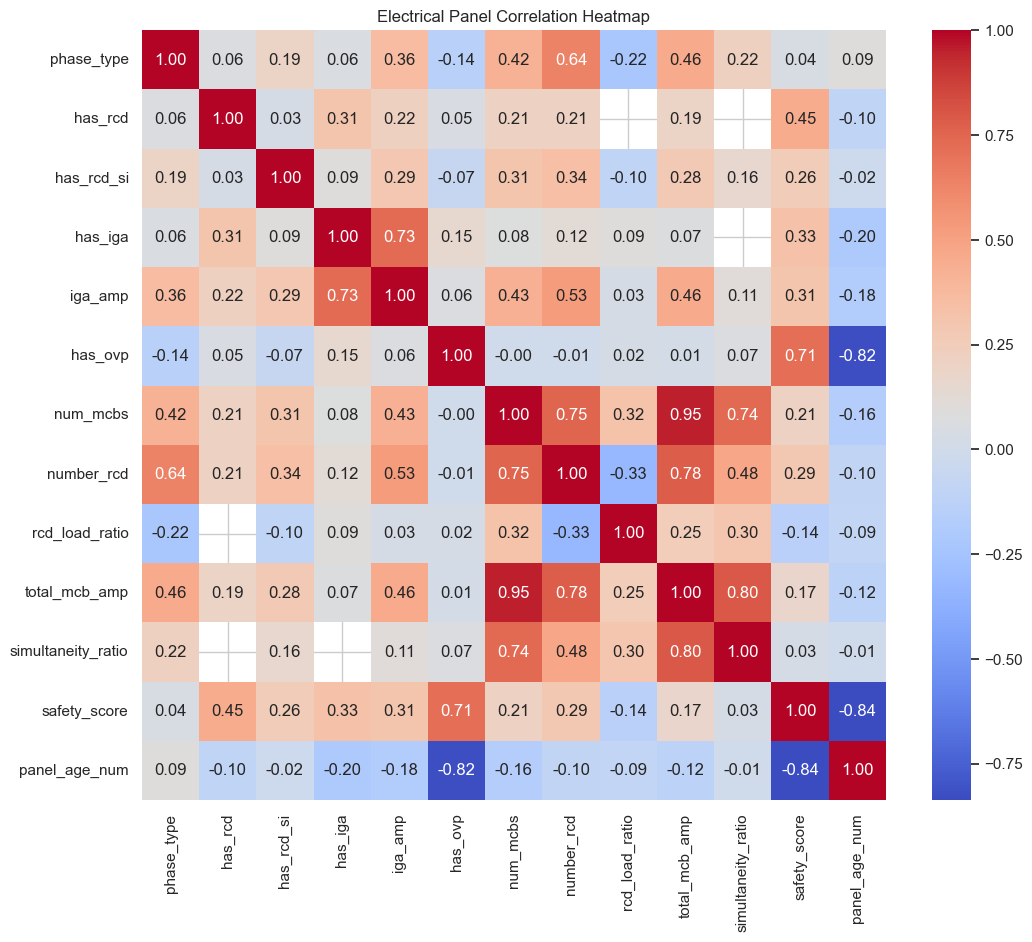

In [ ]:
# Can we move from rule based logic to predictive modeling?
#lets see if there is any correlation between the features. 

#load cleaned data
breakers_cln_scr = pd.read_csv(r'C:\ironhack\labs\breaker-detection-project\data\data\breaker_dataset_scored.csv')

#first  map panel_age to numbers
panel_age_mapping = {
    '< 5 years': 1,
    '5-10 years': 2,
    '10-15 years': 3,
    '15 years': 4,
    '> 20 years': 5
}

breakers_cln_scr['panel_age_num'] = breakers_cln_scr['panel_age'].map(panel_age_mapping)



# Select only numerical columns
numerical_df = breakers_cln_scr.select_dtypes(include=['number'])

# Calculate the matrix
corr_matrix = numerical_df.corr()

# Create the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Electrical Panel Correlation Heatmap')
plt.show()

There is a strong correlation between panel age and has_ovp
The rest is due to the maths performed and data leakage
While many correlations here are mathematical artifacts of our scoring algorithm (Data Leakage), the relationship between Age and OVP is a genuine historical trend that validates our audit's core hypothesis.

In [178]:
# The rate of OVP adoption per age bracket
ovp_rates = breakers.groupby('panel_age')['has_ovp'].mean().sort_index()
print(ovp_rates)


panel_age
10-15 years    0.0
15 years       0.0
5-10 years     0.0
< 5 years      1.0
> 20 years     0.0
Name: has_ovp, dtype: float64


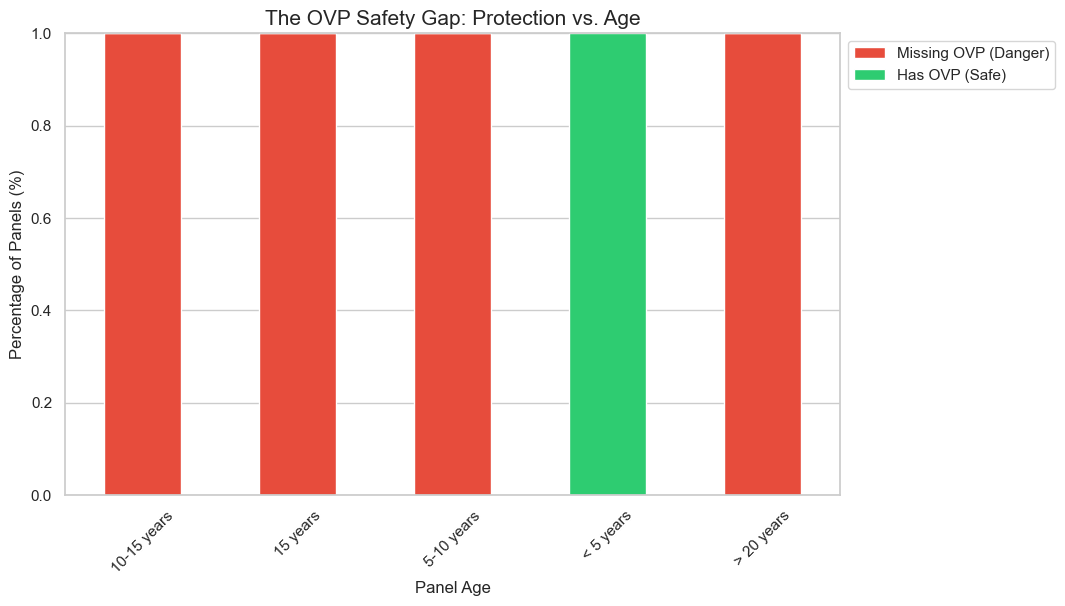

In [179]:
# First, create a cross-tabulation of the data
# We "normalize" the rows so they all add up to 100%
plot_data = pd.crosstab(breakers['panel_age'], breakers['has_ovp'], normalize='index')

# Plotting
plot_data.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(10, 6))

plt.title('The OVP Safety Gap: Protection vs. Age', fontsize=15)
plt.ylabel('Percentage of Panels (%)')
plt.xlabel('Panel Age')
plt.legend(['Missing OVP (Danger)', 'Has OVP (Safe)'], bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.show()


In [180]:
# Raw counts of Age vs OVP
raw_counts = pd.crosstab(breakers['panel_age'], breakers['has_ovp'])
print(raw_counts)


has_ovp       0  1
panel_age         
10-15 years   4  0
15 years     14  0
5-10 years    1  0
< 5 years     0  5
> 20 years   27  0


In [ ]:
# Calculate the risks
risk_new = 1 - breakers[breakers['panel_age'] == '< 5 years']['has_ovp'].mean()
risk_old = 1 - breakers[breakers['panel_age'] == '> 20 years']['has_ovp'].mean()

# Logic to handle the text vs number
if risk_new > 0:
    multiplier = risk_old / risk_new
    message = f"{multiplier:.1f} times"
else:
    message = "infinitely" # or "significantly"

# Print 
print(f"Presentation Insight: You are {message} more likely to lack surge protection if your panel is over 20 years old.")


Presentation Insight: You are infinitely more likely to lack surge protection if your panel is over 20 years old.


C:\Users\PC GAMING\AppData\Local\Temp\ipykernel_92460\3217011490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=breakers, x='panel_age', y='safety_score', order=age_order,


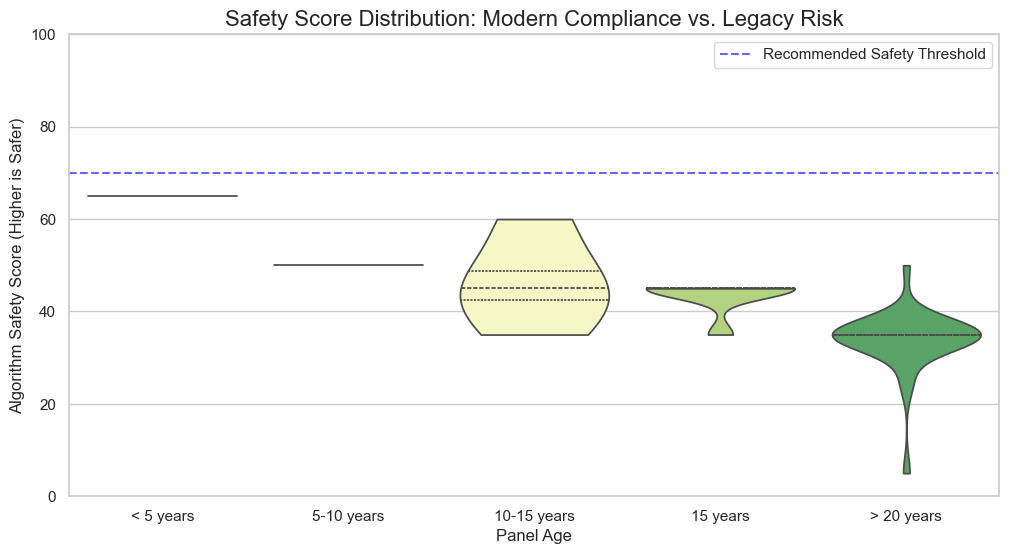

In [ ]:


# Set the order for the chronological age
age_order = ['< 5 years', '5-10 years', '10-15 years', '15 years', '> 20 years']

plt.figure(figsize=(12, 6))

# 2. Create the Violin Plot
# Using 'inner="quartile"' shows the median and spread inside the shapes
sns.violinplot(data=breakers, x='panel_age', y='safety_score', order=age_order, 
               palette='RdYlGn', inner='quartile', cut=0)

# 3. Add a "Passing Grade" reference line at 70 (or wherever you think 'safe' starts)
plt.axhline(70, color='blue', linestyle='--', alpha=0.6, label='Recommended Safety Threshold')

plt.title('Safety Score Distribution: Modern Compliance vs. Legacy Risk', fontsize=16)
plt.ylabel('Algorithm Safety Score (Higher is Safer)')
plt.xlabel('Panel Age')
plt.ylim(0, 100) # Scores stay within this range
plt.legend()
plt.show()


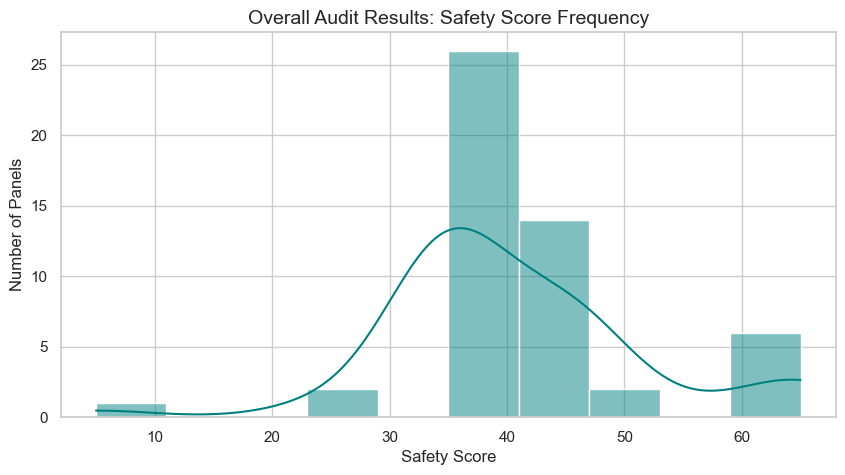

In [184]:
plt.figure(figsize=(10, 5))

# Create a histogram of all scores
sns.histplot(breakers['safety_score'], bins=10, kde=True, color='teal')

plt.title('Overall Audit Results: Safety Score Frequency', fontsize=14)
plt.xlabel('Safety Score')
plt.ylabel('Number of Panels')
plt.show()
